1. Import the Libraries

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, classification_report

2. Load the NSL-KDD Dataset (Training & Testing)

In [2]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

#loading the NSL-KDD training data to a pandas dataframe
train_df=pd.read_csv("..\data\\nsl-kdd\KDDTrain+.txt",names=col_names)
train_df.drop(['difficulty'], axis=1, inplace=True)

#loading the NSL-KDD testing data
test_df=pd.read_csv("..\data\\nsl-kdd\KDDTest-21.txt",names=col_names)
test_df.drop(['difficulty'], axis=1, inplace=True)

print("---Training Data---")
print(f"Shape: {train_df.shape}")
print("\n---Test Data---")
print(f"Shape: {test_df.shape}")

---Training Data---
Shape: (125973, 42)

---Test Data---
Shape: (11850, 42)


In [3]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [4]:
test_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,13,tcp,telnet,SF,118,2425,0,0,0,0,...,10,0.38,0.12,0.04,0.0,0.00,0.00,0.12,0.3,guess_passwd
1,0,udp,private,SF,44,0,0,0,0,0,...,254,1.00,0.01,0.01,0.0,0.00,0.00,0.00,0.0,snmpguess
2,0,tcp,telnet,S3,0,44,0,0,0,0,...,79,0.31,0.61,0.00,0.0,0.21,0.68,0.60,0.0,processtable
3,0,udp,private,SF,53,55,0,0,0,0,...,255,1.00,0.00,0.87,0.0,0.00,0.00,0.00,0.0,normal
4,0,tcp,private,SH,0,0,0,0,0,0,...,1,0.06,1.00,1.00,0.0,1.00,1.00,0.00,0.0,nmap


In [5]:
train_df.tail()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
125968,0,tcp,private,S0,0,0,0,0,0,0,...,25,0.10,0.06,0.00,0.0,1.00,1.0,0.00,0.0,neptune
125969,8,udp,private,SF,105,145,0,0,0,0,...,244,0.96,0.01,0.01,0.0,0.00,0.0,0.00,0.0,normal
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,30,0.12,0.06,0.00,0.0,0.72,0.0,0.01,0.0,normal
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,8,0.03,0.05,0.00,0.0,1.00,1.0,0.00,0.0,neptune
125972,0,tcp,ftp_data,SF,151,0,0,0,0,0,...,77,0.30,0.03,0.30,0.0,0.00,0.0,0.00,0.0,normal


3. Training Data Info

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

4. Check for missing values

In [7]:
train_df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [8]:
print("Total missing values:",train_df.isnull().sum().sum())
train_df=train_df.dropna()

Total missing values: 0


4. Statistical measures of the dataset

In [9]:
train_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


5. Checking the number of rows and columns

In [10]:
print("Before removing duplicates:", train_df.shape)
train_df = train_df.drop_duplicates()
print("After removing duplicates:", train_df.shape)

Before removing duplicates: (125973, 42)
After removing duplicates: (125973, 42)


6. Normal vs Attack Ratio

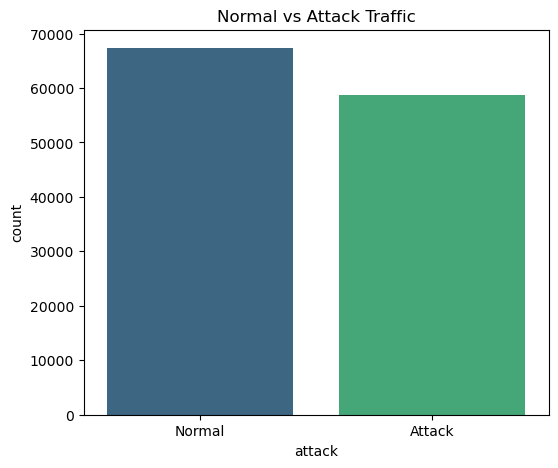

attack
0    0.534583
1    0.465417
Name: proportion, dtype: float64


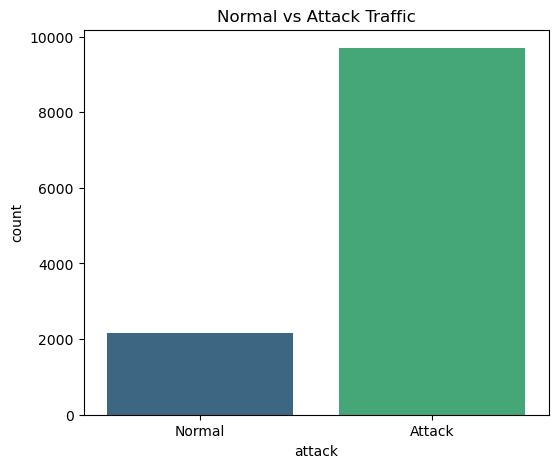

attack
1    0.818397
0    0.181603
Name: proportion, dtype: float64


In [11]:
train_df['attack']=train_df['label'].apply(lambda x: 0 if x=='normal' else 1)
test_df['attack']=test_df['label'].apply(lambda x: 0 if x=='normal' else 1)

plt.figure(figsize=(6,5))
sns.countplot(x="attack",data=train_df, palette="viridis")
plt.title("Normal vs Attack Traffic")
plt.xticks([0,1],["Normal","Attack"])
plt.show()

print(train_df['attack'].value_counts(normalize=True))

plt.figure(figsize=(6,5))
sns.countplot(x="attack",data=test_df, palette="viridis")
plt.title("Normal vs Attack Traffic")
plt.xticks([0,1],["Normal","Attack"])
plt.show()

print(test_df['attack'].value_counts(normalize=True))

7. Graphs

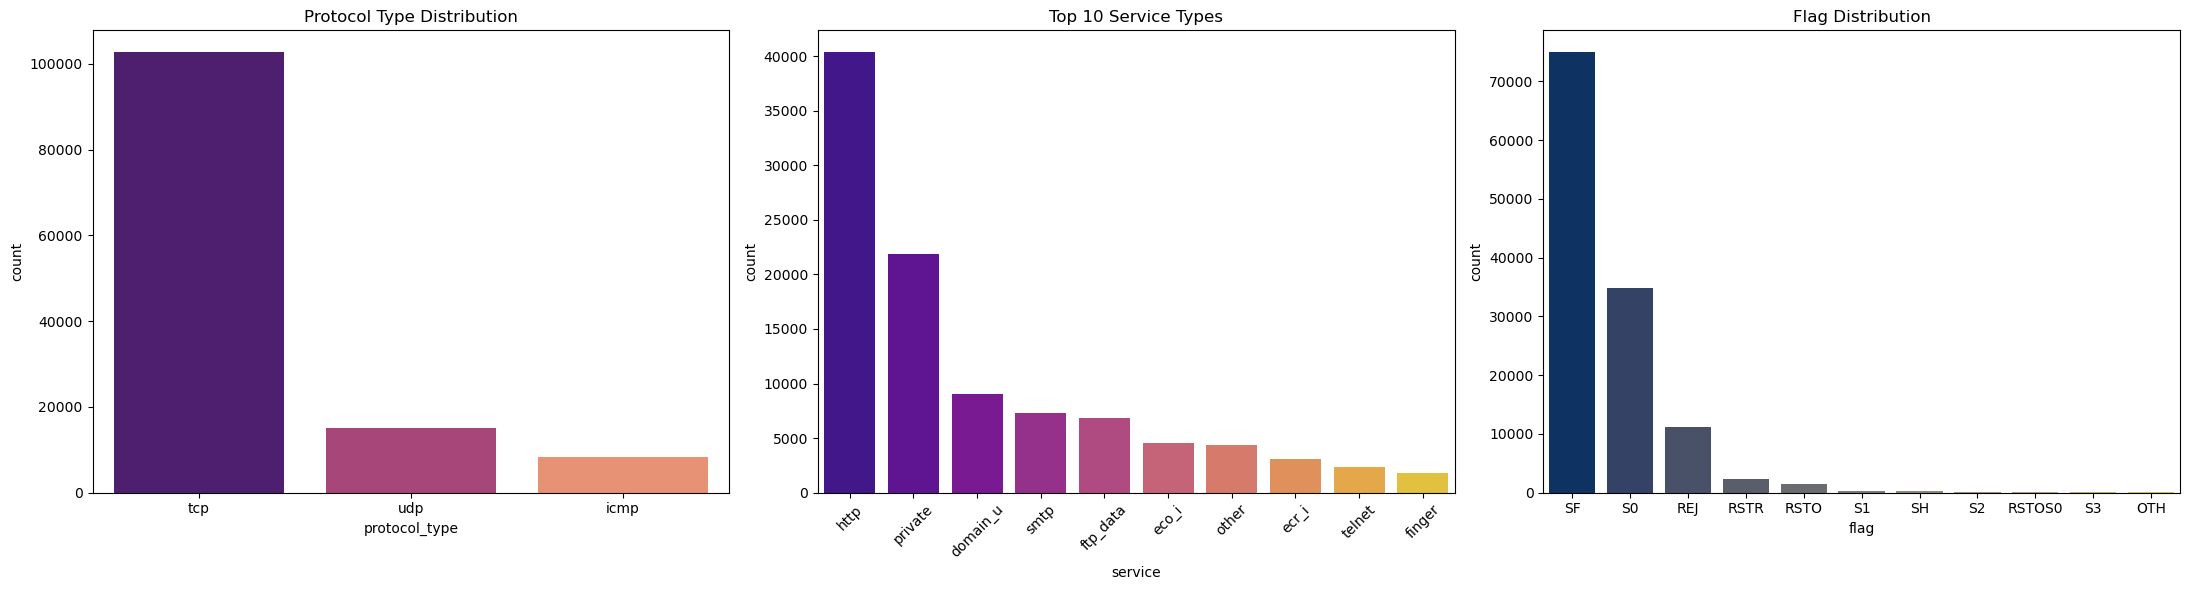

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.countplot(ax=axes[0], x='protocol_type', data=train_df, palette='magma')
axes[0].set_title('Protocol Type Distribution')

sns.countplot(ax=axes[1], x='service', data=train_df, order=train_df['service'].value_counts().iloc[:10].index, palette='plasma')
axes[1].set_title('Top 10 Service Types')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(ax=axes[2], x='flag', data=train_df, order=train_df['flag'].value_counts().index, palette='cividis')
axes[2].set_title('Flag Distribution')

plt.tight_layout()
plt.show()

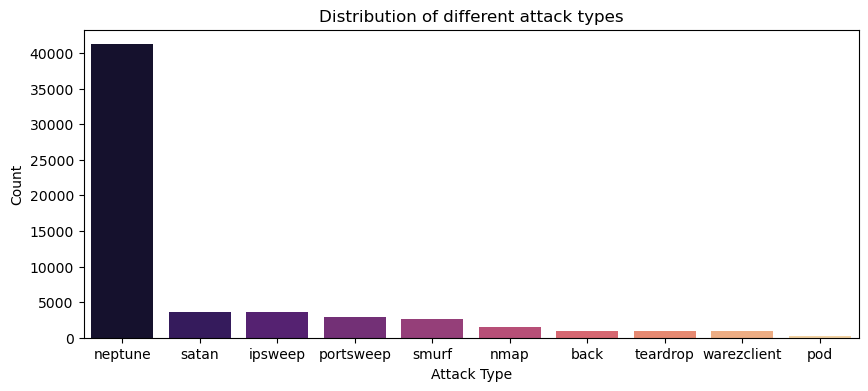

In [13]:
plt.figure(figsize=(10,4))
df_attacks=train_df["label"]
sns.countplot(x=df_attacks, order=df_attacks.value_counts().index[1:11], palette="magma")
plt.title("Distribution of different attack types")
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.show()

8. One-Hot Encoding

In [14]:
categorical_cols=['protocol_type', 'service', 'flag']

x_train=train_df.drop(['label','attack'],axis=1)
y_train=train_df['attack']

x_test=test_df.drop(['label','attack'],axis=1)
y_test=test_df['attack']

x_train=pd.get_dummies(x_train,columns=categorical_cols)
x_test=pd.get_dummies(x_test,columns=categorical_cols)

# Align columns - crucial for ensuring test set has same features as train set
train_cols = x_train.columns
test_cols = x_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    x_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    x_train[c] = 0

X_test_full = x_test[train_cols] # Ensure order is the same
X_train_full = x_train.copy()

print(f"Shape of training data after encoding: {X_train_full.shape}")
print(f"Shape of testing data after encoding: {X_test_full.shape}")

Shape of training data after encoding: (125973, 122)
Shape of testing data after encoding: (11850, 122)


9. Scaling

In [15]:
from sklearn.preprocessing import MinMaxScaler

num_cols = X_train_full.select_dtypes(include=['int64','float64']).columns

# Winsorization
for col in num_cols:
    upper_bound = X_train_full[col].quantile(0.95)
    X_train_full[col] = np.where(X_train_full[col] > upper_bound, upper_bound, X_train_full[col])
    X_test_full[col] = np.where(X_test_full[col] > upper_bound, upper_bound, X_test_full[col])

# Scaling
scaler = MinMaxScaler()
X_train_full[num_cols] = scaler.fit_transform(X_train_full[num_cols])
X_test_full[num_cols] = scaler.transform(X_test_full[num_cols])

In [20]:
def correlation_feature_selection(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = set()
    for column in upper.columns:
        highly_correlated = upper[column][upper[column] > threshold].index.tolist()
        for feature in highly_correlated:
            to_drop.add(feature)
    return list(to_drop)

num_features_to_drop = correlation_feature_selection(X_train_full)

10. Correlation map

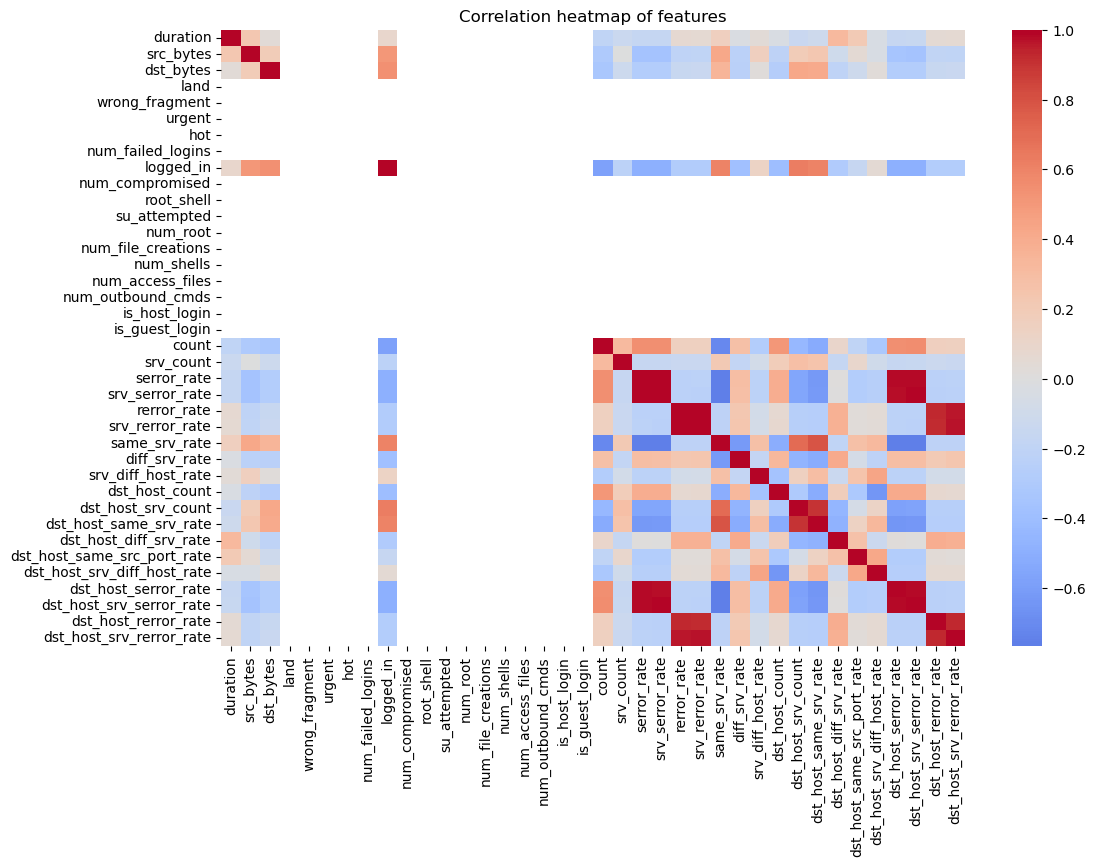

In [21]:
plt.figure(figsize=(12,8))
corr=X_train_full[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap of features")
plt.show()

11. Validation Split

In [22]:
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_full, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [23]:
# 2. Apply Feature Selection to ALL relevant subsets
X_train_res_sel = X_train_full.drop(columns=num_features_to_drop)
X_test_sel = X_test_full.drop(columns=num_features_to_drop)
# The crucial fix: Apply feature selection to the validation split as well!
X_val_sel = X_val.drop(columns=num_features_to_drop) 

In [25]:
y_train_spl = y_train_split # Use the split y_train
X_train_spl = X_train_split.drop(columns=num_features_to_drop) # Use the split X_train

In [27]:
# 12. SMOTE Resampling
# 1. Initialize SMOTE
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)

# 2. Fit and resample the feature-selected training data split
X_train_res, y_train_res = sm.fit_resample(X_train_spl, y_train_spl)

# 3. Print confirmation of the new, balanced shapes
print(f"Original training feature shape: {X_train_spl.shape}")
print(f"SMOTE-resampled training feature shape: {X_train_res.shape}")
print(f"Class distribution after SMOTE:\n{pd.Series(y_train_res).value_counts()}")


Original training feature shape: (100778, 115)
SMOTE-resampled training feature shape: (107748, 115)
Class distribution after SMOTE:
attack
0    53874
1    53874
Name: count, dtype: int64


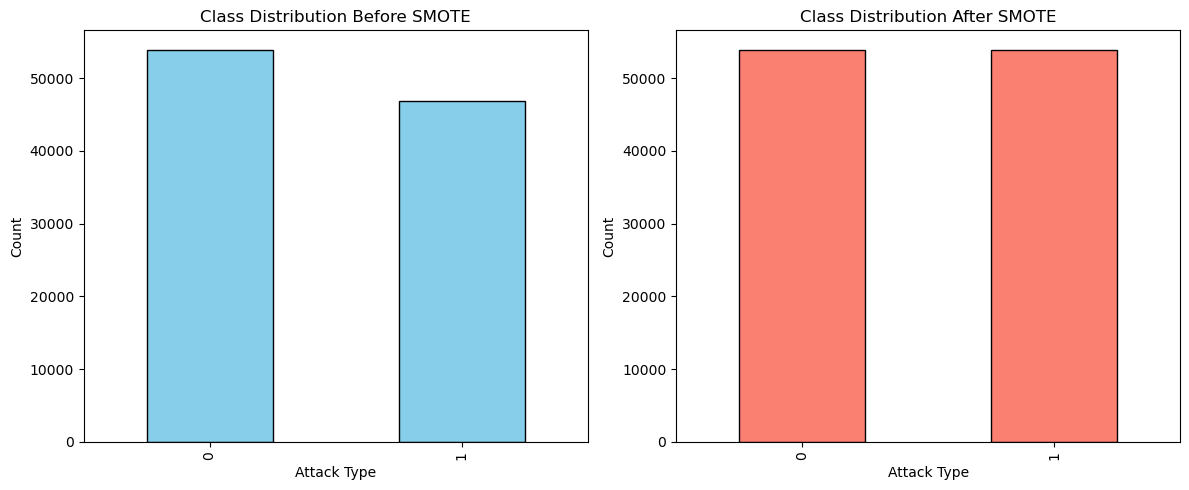

In [28]:
# --- SMOTE Distribution Plots ---
# --- Distribution before SMOTE ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
pd.Series(y_train_spl).value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Attack Type")
plt.ylabel("Count")

# --- Distribution after SMOTE ---
plt.subplot(1,2,2)
pd.Series(y_train_res).value_counts().plot(kind='bar', color='salmon', edgecolor='black')
plt.title("Class Distribution After SMOTE")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

--- Full Model Evaluation (Winsorized + Feature Selected Data) ---

## Logistic Regression
### Training Accuracy: 97.7225%
### Testing Accuracy: 49.7553%

**Validation Classification Report:**

| | precision | recall | f1-score | support |
| :--- | :--- | :--- | :--- | :--- |
| **Normal** | 0.9750 | 0.9811 | 0.9780 | 13469 |
| **Attack** | 0.9781 | 0.9711 | 0.9746 | 11726 |
| **accuracy** | | | 0.9764 | 25195 |
| **macro avg** | 0.9765 | 0.9761 | 0.9763 | 25195 |
| **weighted avg**| 0.9764 | 0.9764 | 0.9764 | 25195 |


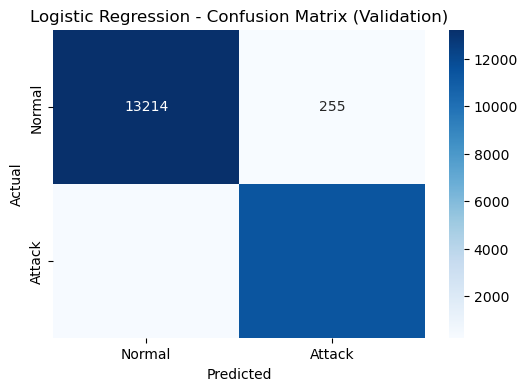


Logistic Regression - Test Accuracy: 49.7553%

**Test Classification Report:**

| | precision | recall | f1-score | support |
| :--- | :--- | :--- | :--- | :--- |
| **Normal** | 0.2141 | 0.6617 | 0.3236 | 2152 |
| **Attack** | 0.8600 | 0.4611 | 0.6003 | 9698 |
| **accuracy** | | | 0.4976 | 11850 |
| **macro avg** | 0.5371 | 0.5614 | 0.4620 | 11850 |
| **weighted avg**| 0.7427 | 0.4976 | 0.5501 | 11850 |


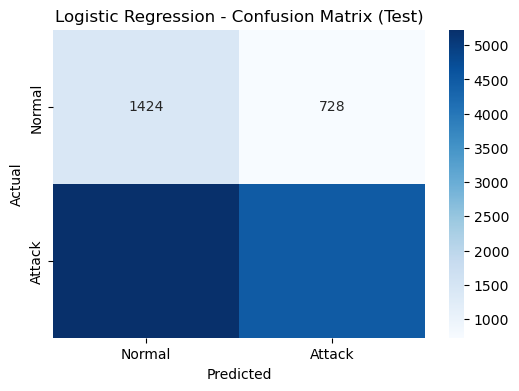


## Random Forest
### Training Accuracy: 99.9926%
### Testing Accuracy: 54.5992%

**Validation Classification Report:**

| | precision | recall | f1-score | support |
| :--- | :--- | :--- | :--- | :--- |
| **Normal** | 0.9984 | 0.9992 | 0.9988 | 13469 |
| **Attack** | 0.9991 | 0.9981 | 0.9986 | 11726 |
| **accuracy** | | | 0.9987 | 25195 |
| **macro avg** | 0.9987 | 0.9987 | 0.9987 | 25195 |
| **weighted avg**| 0.9987 | 0.9987 | 0.9987 | 25195 |


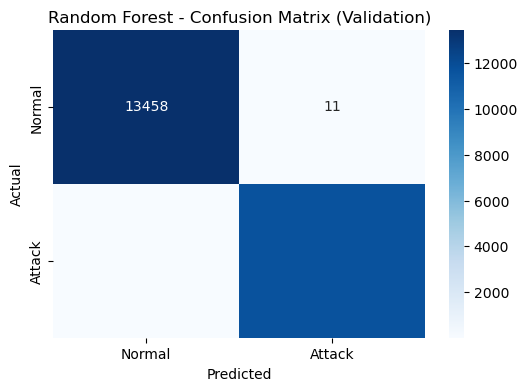


Random Forest - Test Accuracy: 54.5992%

**Test Classification Report:**

| | precision | recall | f1-score | support |
| :--- | :--- | :--- | :--- | :--- |
| **Normal** | 0.2700 | 0.8806 | 0.4133 | 2152 |
| **Attack** | 0.9468 | 0.4717 | 0.6297 | 9698 |
| **accuracy** | | | 0.5460 | 11850 |
| **macro avg** | 0.6084 | 0.6762 | 0.5215 | 11850 |
| **weighted avg**| 0.8239 | 0.5460 | 0.5904 | 11850 |


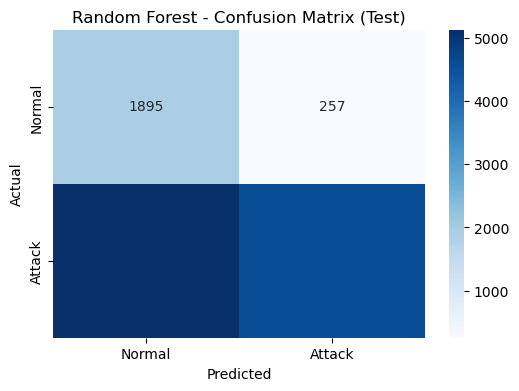


## Linear SVM
### Training Accuracy: 97.7336%
### Testing Accuracy: 48.8270%

**Validation Classification Report:**

| | precision | recall | f1-score | support |
| :--- | :--- | :--- | :--- | :--- |
| **Normal** | 0.9743 | 0.9825 | 0.9784 | 13469 |
| **Attack** | 0.9797 | 0.9702 | 0.9749 | 11726 |
| **accuracy** | | | 0.9768 | 25195 |
| **macro avg** | 0.9770 | 0.9764 | 0.9767 | 25195 |
| **weighted avg**| 0.9768 | 0.9768 | 0.9768 | 25195 |


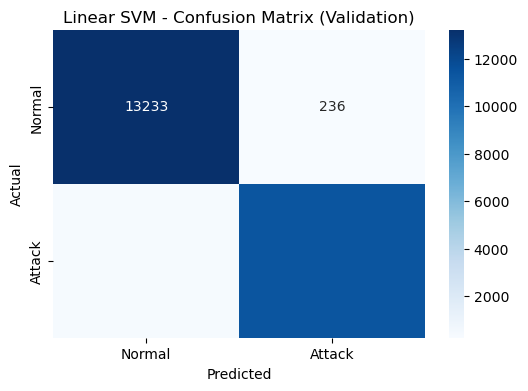


Linear SVM - Test Accuracy: 48.8270%

**Test Classification Report:**

| | precision | recall | f1-score | support |
| :--- | :--- | :--- | :--- | :--- |
| **Normal** | 0.2107 | 0.6617 | 0.3196 | 2152 |
| **Attack** | 0.8570 | 0.4498 | 0.5899 | 9698 |
| **accuracy** | | | 0.4883 | 11850 |
| **macro avg** | 0.5338 | 0.5557 | 0.4548 | 11850 |
| **weighted avg**| 0.7396 | 0.4883 | 0.5408 | 11850 |


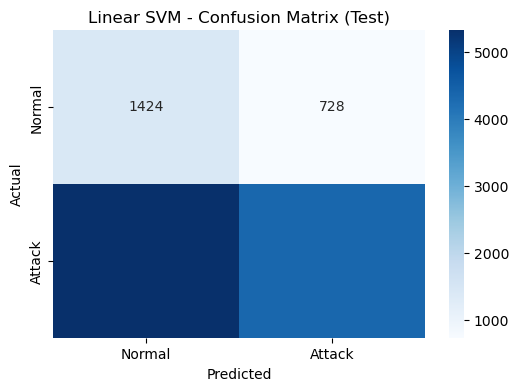


## Voting Classifier
### Training Accuracy: 97.9099%
### Testing Accuracy: 49.0464%

**Validation Classification Report:**

| | precision | recall | f1-score | support |
| :--- | :--- | :--- | :--- | :--- |
| **Normal** | 0.9763 | 0.9837 | 0.9800 | 13469 |
| **Attack** | 0.9812 | 0.9725 | 0.9768 | 11726 |
| **accuracy** | | | 0.9785 | 25195 |
| **macro avg** | 0.9787 | 0.9781 | 0.9784 | 25195 |
| **weighted avg**| 0.9785 | 0.9785 | 0.9785 | 25195 |


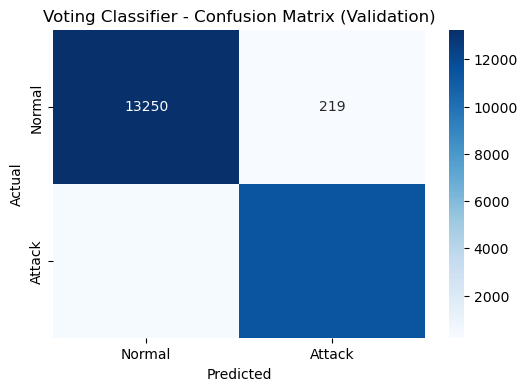


Voting Classifier - Test Accuracy: 49.0464%

**Test Classification Report:**

| | precision | recall | f1-score | support |
| :--- | :--- | :--- | :--- | :--- |
| **Normal** | 0.2119 | 0.6640 | 0.3213 | 2152 |
| **Attack** | 0.8584 | 0.4519 | 0.5921 | 9698 |
| **accuracy** | | | 0.4905 | 11850 |
| **macro avg** | 0.5351 | 0.5580 | 0.4567 | 11850 |
| **weighted avg**| 0.7410 | 0.4905 | 0.5429 | 11850 |


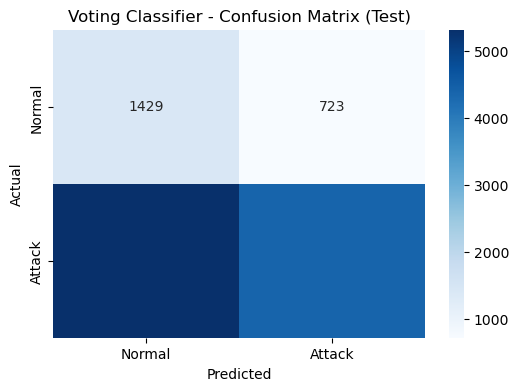

In [29]:
lr_sel = LogisticRegression(max_iter=5000, random_state=42) 
rf_sel = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
svc_sel = LinearSVC(random_state=42, max_iter=5000) 

lr_sel.fit(X_train_res, y_train_res)
rf_sel.fit(X_train_res, y_train_res)
svc_sel.fit(X_train_res, y_train_res)

# Voting Classifier (Hard Voting)
voting_clf = VotingClassifier(
    estimators=[('lr', lr_sel), ('rf', rf_sel), ('svc', svc_sel)],
    voting='hard',
    n_jobs=-1
)
voting_clf.fit(X_train_res, y_train_res)

models = {
    "Logistic Regression": lr_sel,
    "Random Forest": rf_sel,
    "Linear SVM": svc_sel,
    "Voting Classifier": voting_clf
}

# --- 3. Generate Metrics and Plots ---
print("--- Full Model Evaluation (Winsorized + Feature Selected Data) ---")

for name, model in models.items():
    # 1. Training Performance 
    y_train_pred = model.predict(X_train_res)
    train_acc = accuracy_score(y_train_res, y_train_pred)

    # 2. Validation Performance 
    y_val_pred = model.predict(X_val_sel) # Use the feature-selected validation set
    val_acc = accuracy_score(y_val, y_val_pred)
    val_cm = confusion_matrix(y_val, y_val_pred)
    val_report_dict = classification_report(y_val, y_val_pred, target_names=["Normal", "Attack"], output_dict=True)

    # 3. Test Performance
    y_test_pred = model.predict(X_test_sel)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_cm = confusion_matrix(y_test, y_test_pred)
    test_report_dict = classification_report(y_test, y_test_pred, target_names=["Normal", "Attack"], output_dict=True)

    # Print the report in the requested format
    print(f"\n## {name}")
    print(f"### Training Accuracy: {train_acc*100:.4f}%")
    print(f"### Testing Accuracy: {test_acc*100:.4f}%")
    
    # --- Validation Metrics ---
    print("\n**Validation Classification Report:**\n")
    print("| | precision | recall | f1-score | support |")
    print("| :--- | :--- | :--- | :--- | :--- |")
    print(f"| **Normal** | {val_report_dict['Normal']['precision']:.4f} | {val_report_dict['Normal']['recall']:.4f} | {val_report_dict['Normal']['f1-score']:.4f} | {val_report_dict['Normal']['support']} |")
    print(f"| **Attack** | {val_report_dict['Attack']['precision']:.4f} | {val_report_dict['Attack']['recall']:.4f} | {val_report_dict['Attack']['f1-score']:.4f} | {val_report_dict['Attack']['support']} |")
    print(f"| **accuracy** | | | {val_report_dict['accuracy']:.4f} | {val_report_dict['macro avg']['support']} |")
    print(f"| **macro avg** | {val_report_dict['macro avg']['precision']:.4f} | {val_report_dict['macro avg']['recall']:.4f} | {val_report_dict['macro avg']['f1-score']:.4f} | {val_report_dict['macro avg']['support']} |")
    print(f"| **weighted avg**| {val_report_dict['weighted avg']['precision']:.4f} | {val_report_dict['weighted avg']['recall']:.4f} | {val_report_dict['weighted avg']['f1-score']:.4f} | {val_report_dict['weighted avg']['support']} |")
    
    # Validation CM Plot
    plt.figure(figsize=(6,4))
    sns.heatmap(val_cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    plt.title(f"{name} - Confusion Matrix (Validation)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # --- Test Metrics ---
    print(f"\n{name} - Test Accuracy: {test_acc*100:.4f}%")
    print("\n**Test Classification Report:**\n")
    print("| | precision | recall | f1-score | support |")
    print("| :--- | :--- | :--- | :--- | :--- |")
    print(f"| **Normal** | {test_report_dict['Normal']['precision']:.4f} | {test_report_dict['Normal']['recall']:.4f} | {test_report_dict['Normal']['f1-score']:.4f} | {test_report_dict['Normal']['support']} |")
    print(f"| **Attack** | {test_report_dict['Attack']['precision']:.4f} | {test_report_dict['Attack']['recall']:.4f} | {test_report_dict['Attack']['f1-score']:.4f} | {test_report_dict['Attack']['support']} |")
    print(f"| **accuracy** | | | {test_report_dict['accuracy']:.4f} | {test_report_dict['macro avg']['support']} |")
    print(f"| **macro avg** | {test_report_dict['macro avg']['precision']:.4f} | {test_report_dict['macro avg']['recall']:.4f} | {test_report_dict['macro avg']['f1-score']:.4f} | {test_report_dict['macro avg']['support']} |")
    print(f"| **weighted avg**| {test_report_dict['weighted avg']['precision']:.4f} | {test_report_dict['weighted avg']['recall']:.4f} | {test_report_dict['weighted avg']['f1-score']:.4f} | {test_report_dict['weighted avg']['support']} |")
    
    # Test CM Plot
    plt.figure(figsize=(6,4))
    sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    plt.title(f"{name} - Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



--- ROC-AUC Curves (Test Data) ---


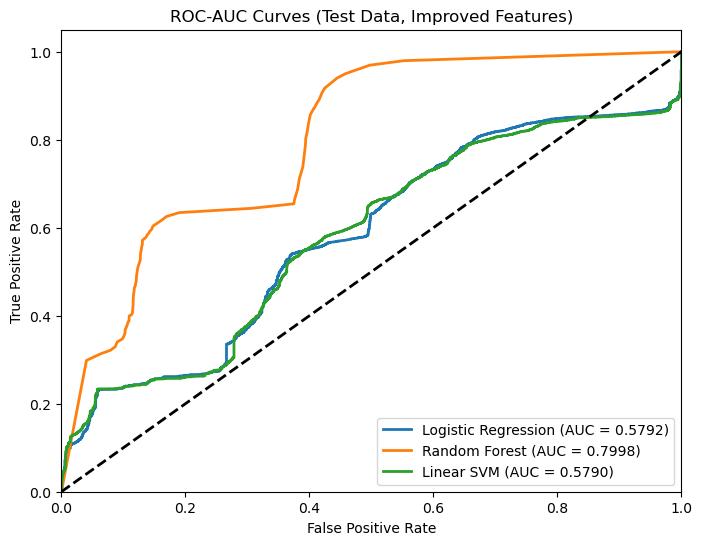

In [30]:
print("\n--- ROC-AUC Curves (Test Data) ---")
plt.figure(figsize=(8,6))

for name, model in models.items():
    if name == "Voting Classifier":
        continue

    # Use X_test_sel, the feature-selected, column-ordered test set
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_sel)[:, 1]
    elif hasattr(model, "decision_function"):
        # LinearSVC uses decision_function, which needs normalization for ROC
        y_score = model.decision_function(X_test_sel)
        y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min())
    
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves (Test Data, Improved Features)")
plt.legend(loc="lower right")
plt.show()